<a href="https://colab.research.google.com/github/fabionunesdepaula/fabionunesdepaula.github.io/blob/main/md_aula02_EDA_Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# IMPORTAÇÃO DAS PRINCIPAIS BIBLIOTECAS
# ============================================================

# NumPy: operações matemáticas e numéricas.
import numpy as np

# Pandas: estruturas de dados, especialmente DataFrames.
import pandas as pd

# Matplotlib: construção e personalização de gráficos.
import matplotlib.pyplot as plt

# Seaborn: gráficos estatísticos construídos sobre o Matplotlib.
import seaborn as sns

# Scikit-learn: biblioteca de Machine Learning.
# Aqui utilizaremos o módulo datasets para carregar o Iris.
from sklearn.datasets import load_iris

In [ ]:
# ============================================================
# CARREGANDO O DATASET IRIS
# ============================================================

iris = load_iris() # load_iris() carrega o conjunto Iris diretamente do scikit-learn.

print(iris.keys()) # Verificar os nomes das variáveis disponíveis no objeto.
print(iris.data[:5]) # Exibe as primeiras 5 linhas dos dados

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [ ]:
# ============================================================
# CRIAÇÃO DO DATAFRAME
# ============================================================

# iris.data contém os quatro atributos quantitativos.
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# iris.target contém a classe codificada como 0, 1 e 2.
df["target"] = iris.target

# iris.target_names contém os nomes das três espécies.
# Fazemos o mapeamento do número da classe para o nome da espécie.
df["species"] = df["target"].map(
    dict(enumerate(iris.target_names))
)

# Exibimos as primeiras linhas.
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
# ============================================================
# DIMENSÕES DA BASE
# ============================================================

# shape retorna (linhas, colunas).
print("Número de observações:", df.shape[0])
print("Número de atributos:", df.shape[1])

Número de observações: 150
Número de atributos: 6


In [ ]:
# ============================================================
# TIPOS DOS ATRIBUTOS
# ============================================================

# dtypes mostra o tipo armazenado em cada coluna.
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
target,int64
species,object


In [ ]:
# ============================================================
# VALORES AUSENTES
# ============================================================

# isnull() identifica valores ausentes.
# sum() conta quantos existem em cada coluna.

df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
species,0


In [ ]:
# ============================================================
# DISTRIBUIÇÃO DAS CLASSES
# ============================================================

# value_counts() conta a quantidade de exemplos de cada classe.
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
# ============================================================
# LISTANDO AS VARIÁVEIS QUANTITATIVAS
# ============================================================

# Estas quatro variáveis representam medidas físicas das flores.
variaveis_quantitativas = iris.feature_names

print("Variáveis quantitativas:")
for coluna in variaveis_quantitativas:
    print("-", coluna)

Variáveis quantitativas:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [ ]:
# ============================================================
# FREQUÊNCIA
# ============================================================

for coluna in df.columns:
    print("=" * 70)
    print(f"Frequência dos valores — {coluna}")
    print(df[coluna].value_counts().sort_index().head(1))

Frequência dos valores — sepal length (cm)
sepal length (cm)
4.3    1
Name: count, dtype: int64
Frequência dos valores — sepal width (cm)
sepal width (cm)
2.0    1
Name: count, dtype: int64
Frequência dos valores — petal length (cm)
petal length (cm)
1.0    1
Name: count, dtype: int64
Frequência dos valores — petal width (cm)
petal width (cm)
0.1    5
Name: count, dtype: int64
Frequência dos valores — target
target
0    50
Name: count, dtype: int64
Frequência dos valores — species
species
setosa    50
Name: count, dtype: int64


In [ ]:
# ============================================================
# MODA
# ============================================================

for coluna in df.columns:
    modas = df[coluna].mode().tolist()
    print(f"{coluna}: {modas}")


sepal length (cm): [5.0]
sepal width (cm): [3.0]
petal length (cm): [1.4, 1.5]
petal width (cm): [0.2]
target: [0, 1, 2]
species: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [ ]:
# ============================================================
# MÉDIA, MEDIANA E DESVIO-PADRÃO
# ============================================================

estatisticas_central = pd.DataFrame({
    "Média": df[variaveis_quantitativas].mean(),
    "Mediana": df[variaveis_quantitativas].median(),
    "Desvio-padrão": df[variaveis_quantitativas].std()
})

estatisticas_central.round(4)

,Média,Mediana,Desvio-padrão
sepal length (cm),5.8433,5.80,0.8281
sepal width (cm),3.0573,3.00,0.4359
petal length (cm),3.7580,4.35,1.7653
petal width (cm),1.1993,1.30,0.7622


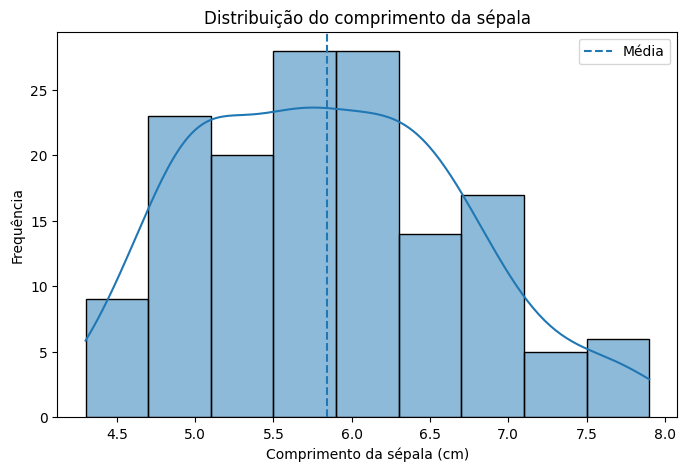

In [ ]:
# ============================================================
# EXEMPLO VISUAL DA DISPERSÃO
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="sepal length (cm)",
    kde=True
)

plt.axvline(
    df["sepal length (cm)"].mean(),
    linestyle="--",
    label="Média"
)

plt.title("Distribuição do comprimento da sépala")
plt.xlabel("Comprimento da sépala (cm)")
plt.ylabel("Frequência")
plt.legend()
plt.show()

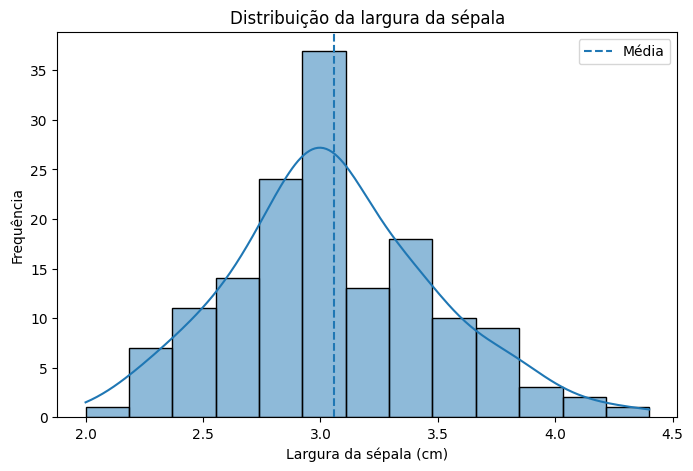

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="sepal width (cm)",
    kde=True
)

plt.axvline(
    df["sepal width (cm)"].mean(),
    linestyle="--",
    label="Média"
)

plt.title("Distribuição da largura da sépala")
plt.xlabel("Largura da sépala (cm)")
plt.ylabel("Frequência")
plt.legend()
plt.show()

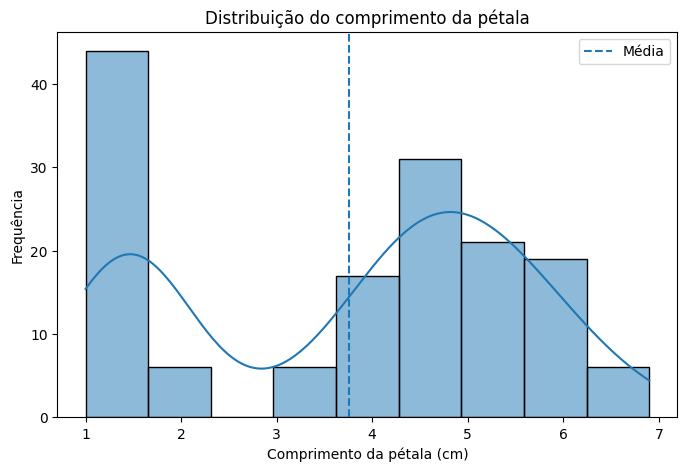

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="petal length (cm)",
    kde=True
)

plt.axvline(
    df["petal length (cm)"].mean(),
    linestyle="--",
    label="Média"
)

plt.title("Distribuição do comprimento da pétala")
plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Frequência")
plt.legend()
plt.show()

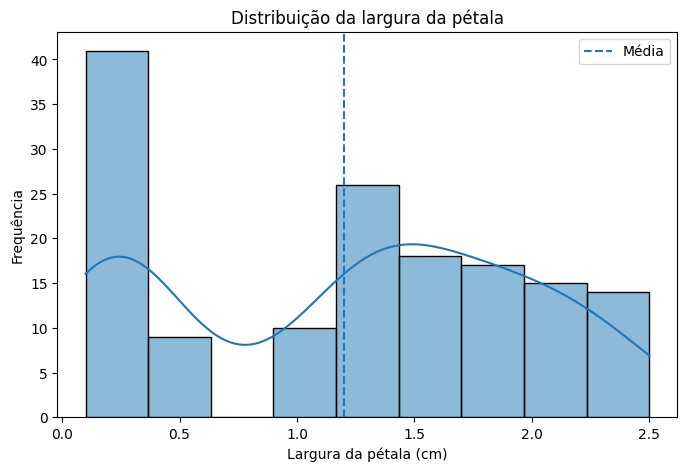

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="petal width (cm)",
    kde=True
)

plt.axvline(
    df["petal width (cm)"].mean(),
    linestyle="--",
    label="Média"
)

plt.title("Distribuição da largura da pétala")
plt.xlabel("Largura da pétala (cm)")
plt.ylabel("Frequência")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# Q1, MEDIANA E Q3
# ============================================================

quartis = pd.DataFrame({
    "Q1": df[variaveis_quantitativas].quantile(0.25),
    "Q2": df[variaveis_quantitativas].quantile(0.50),
    "Q3": df[variaveis_quantitativas].quantile(0.75)
})

quartis.round(4)

,Q1,Q2,Q3
sepal length (cm),5.1,5.80,6.4
sepal width (cm),2.8,3.00,3.3
petal length (cm),1.6,4.35,5.1
petal width (cm),0.3,1.30,1.8


In [ ]:
# ============================================================
# OBLIQUIDADE
# ============================================================

obliquidade = df[variaveis_quantitativas].skew()
obliquidade.round(4)


,0
sepal length (cm),0.3149
sepal width (cm),0.3190
petal length (cm),-0.2749
petal width (cm),-0.1030


In [ ]:
# ============================================================
# CURTOSE
# ============================================================

curtose = df[variaveis_quantitativas].kurt()

curtose.round(4)

,0
sepal length (cm),-0.5521
sepal width (cm),0.2282
petal length (cm),-1.4021
petal width (cm),-1.3406


In [ ]:
# ============================================================
# MATRIZ DE COVARIÂNCIA
# ============================================================

matriz_covariancia = df[variaveis_quantitativas].cov()

matriz_covariancia.round(4)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.6857,-0.0424,1.2743,0.5163
sepal width (cm),-0.0424,0.1900,-0.3297,-0.1216
petal length (cm),1.2743,-0.3297,3.1163,1.2956
petal width (cm),0.5163,-0.1216,1.2956,0.5810


In [ ]:
# ============================================================
# MATRIZ DE CORRELAÇÃO
# ============================================================

matriz_correlacao = df[variaveis_quantitativas].corr()

matriz_correlacao.round(4)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.0000,-0.1176,0.8718,0.8179
sepal width (cm),-0.1176,1.0000,-0.4284,-0.3661
petal length (cm),0.8718,-0.4284,1.0000,0.9629
petal width (cm),0.8179,-0.3661,0.9629,1.0000


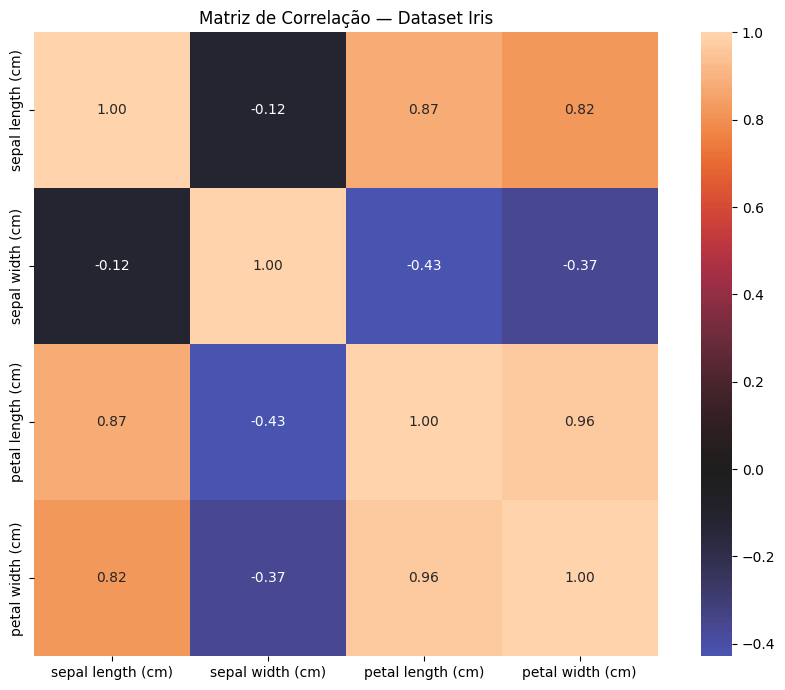

In [ ]:
# ============================================================
# HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    center=0,
    square=True
)

plt.title("Matriz de Correlação — Dataset Iris")
plt.tight_layout()
plt.show()

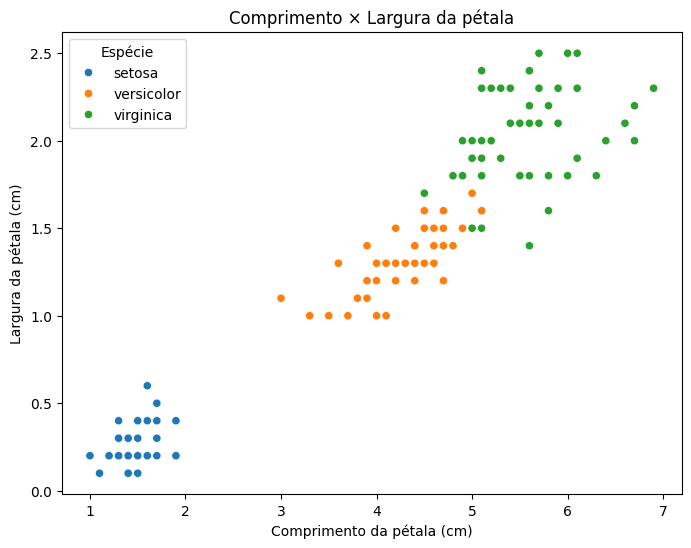

In [ ]:
# ============================================================
# RELAÇÃO ENTRE COMPRIMENTO E LARGURA DA PÉTALA
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species" # Adiciona uma cor para cada espécie
)

plt.title("Comprimento × Largura da pétala")
plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Largura da pétala (cm)")
plt.legend(title="Espécie")
plt.show()

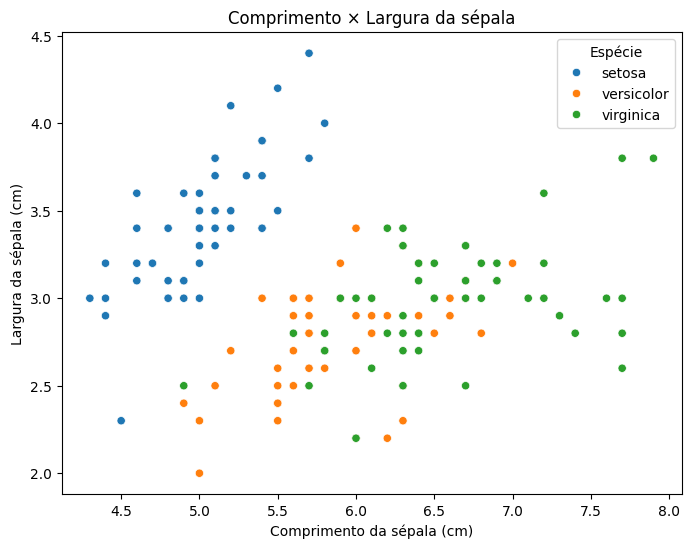

In [ ]:
# ============================================================
# RELAÇÃO ENTRE COMPRIMENTO E LARGURA DA SÉPALA
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species" # Adiciona uma cor para cada espécie
)

plt.title("Comprimento × Largura da sépala")
plt.xlabel("Comprimento da sépala (cm)")
plt.ylabel("Largura da sépala (cm)")
plt.legend(title="Espécie")
plt.show()

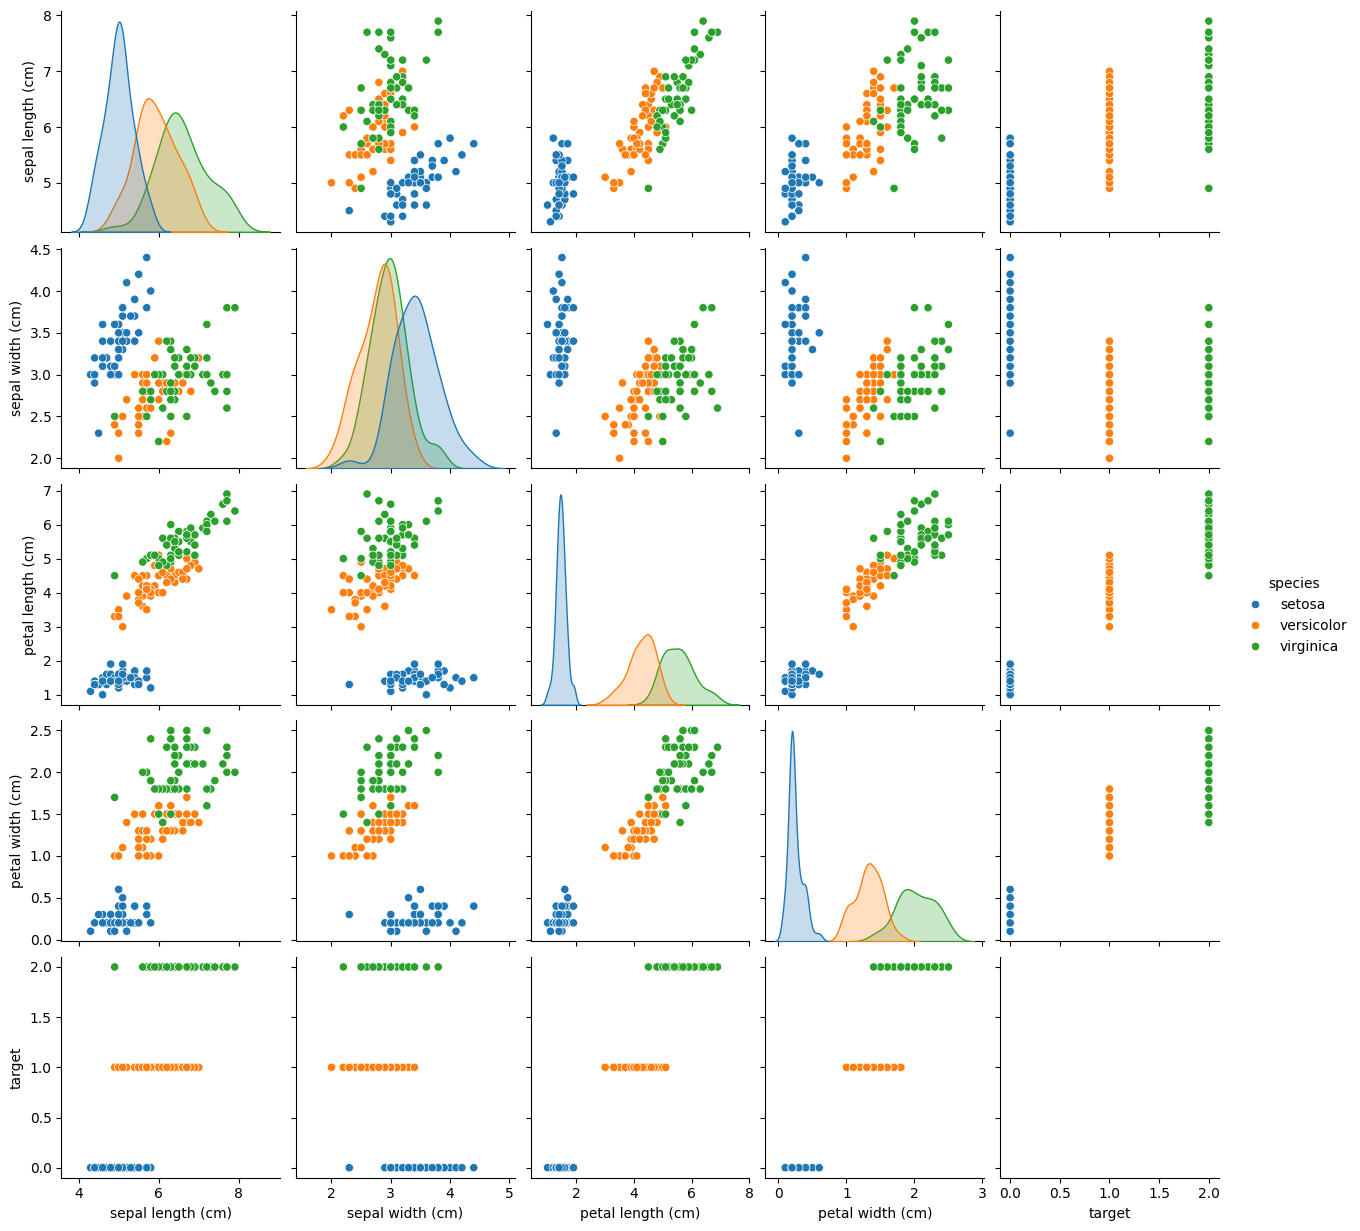

In [ ]:
sns.pairplot(df, hue="species")
plt.show()

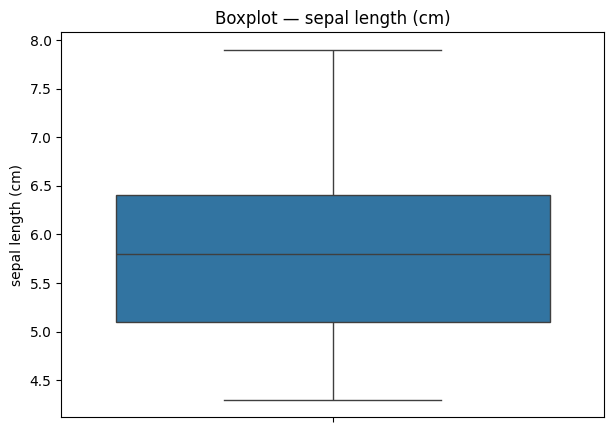

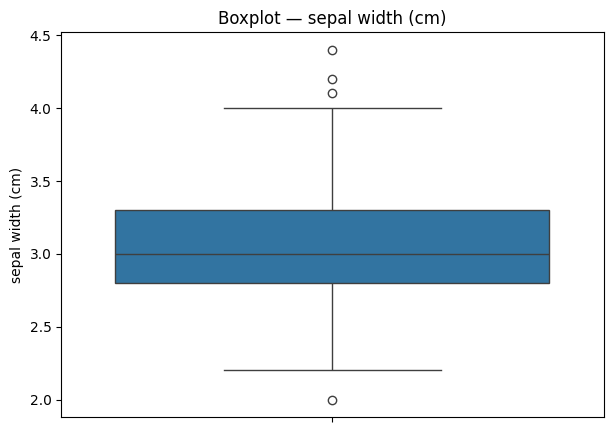

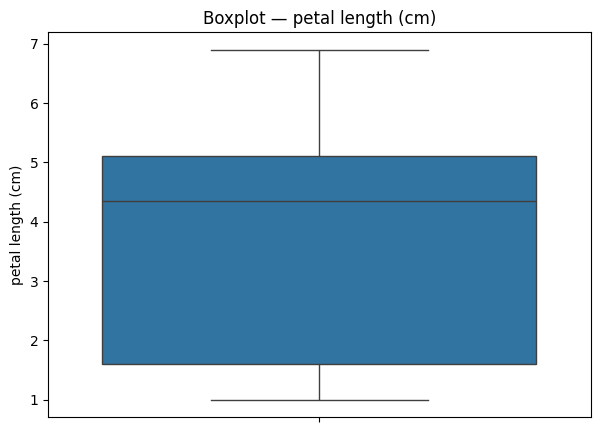

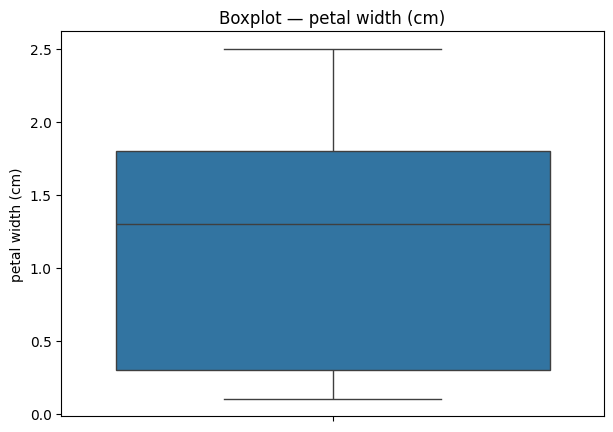

In [ ]:
# ============================================================
# BOXPLOTS DOS ATRIBUTOS
# ============================================================

for coluna in variaveis_quantitativas:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        y=df[coluna]
    )

    plt.title(f"Boxplot — {coluna}")
    plt.ylabel(coluna)
    plt.show()

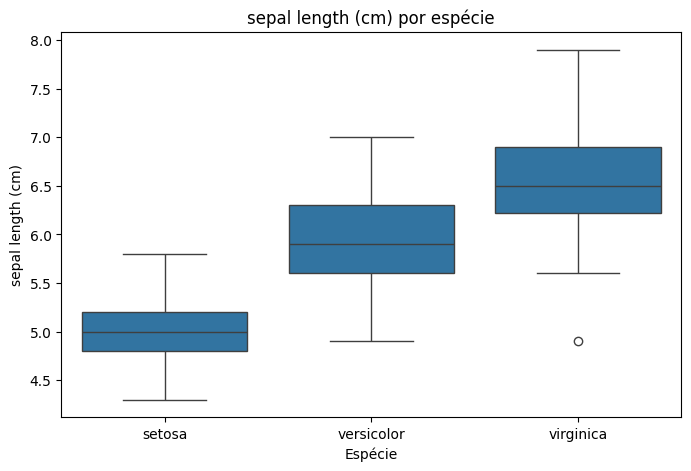

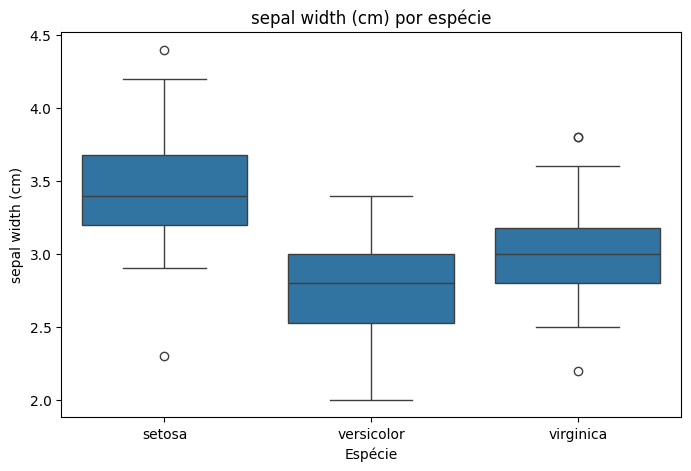

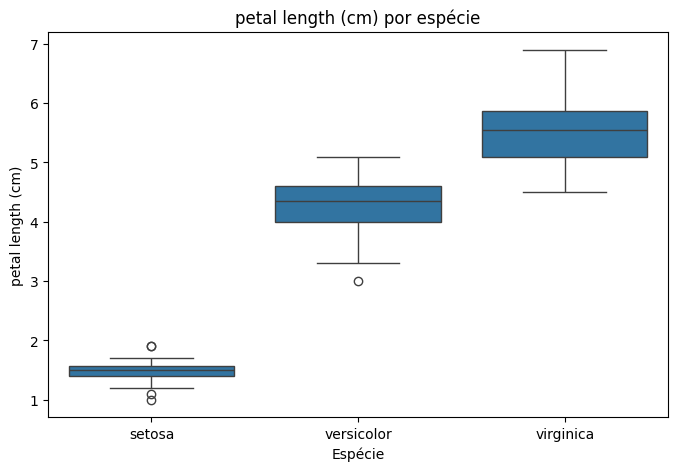

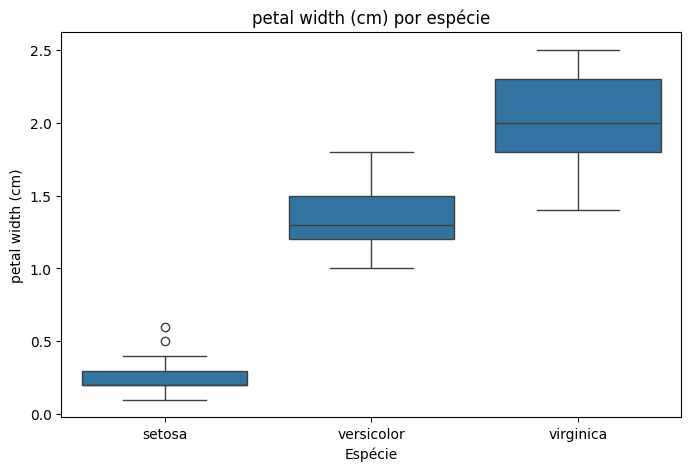

In [ ]:
# ============================================================
# BOXPLOTS POR ESPÉCIE
# ============================================================

for coluna in variaveis_quantitativas:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="species",
        y=coluna
    )

    plt.title(f"{coluna} por espécie")
    plt.xlabel("Espécie")
    plt.ylabel(coluna)
    plt.show()

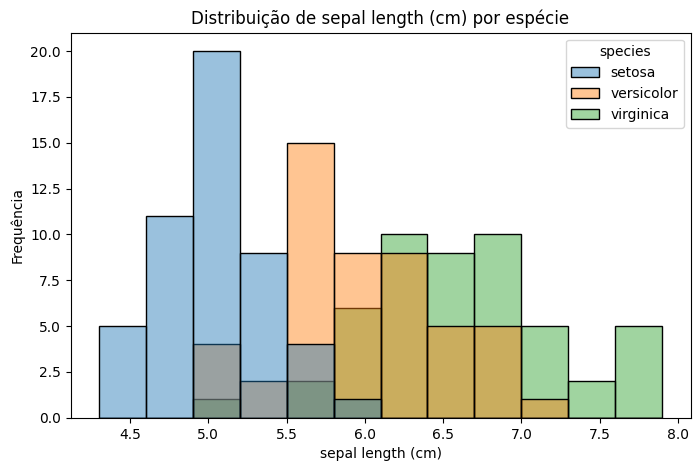

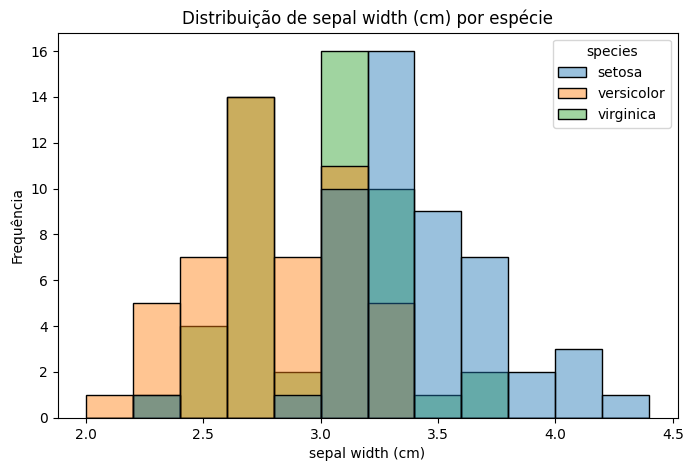

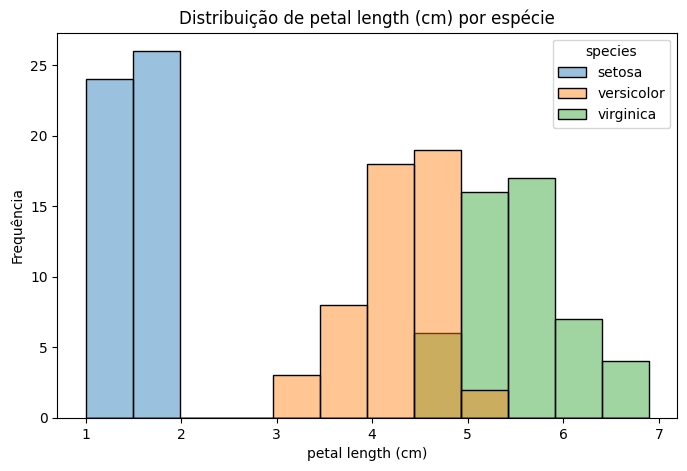

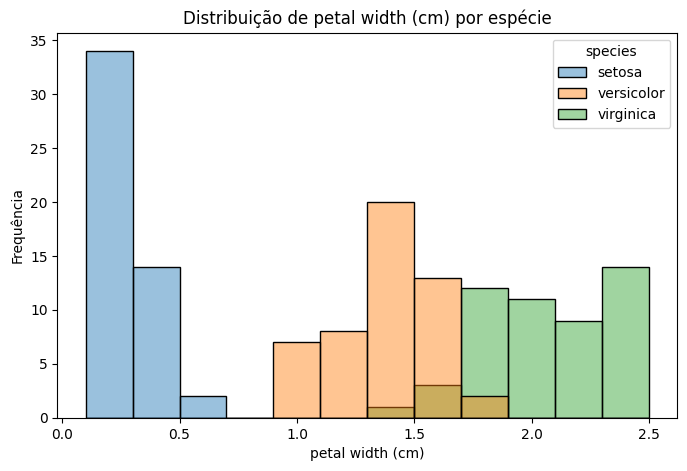

In [ ]:
# ============================================================
# HISTOGRAMAS DOS ATRIBUTOS
# ============================================================

for coluna in variaveis_quantitativas:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=coluna,
        hue="species",
        bins=12,
        multiple="layer",
        alpha=0.45
    )

    plt.title(f"Distribuição de {coluna} por espécie")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.show()
